# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/raw/`
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

Dimensiones del dataset de entrenamiento: (16512, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY
1,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN
2,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND
3,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND
4,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN



--- INFO GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.3+ MB

--- ESTADÍSTICAS DESCRIPTIVAS ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,16512.000000,16512.000000,16512.000000,16512.000000,16344.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7274
mean,-119.573125,35.637746,28.577156,2639.402798,538.949094,1425.513929,499.990189,3.870428,206333.518653,NaN
std,2.000624,2.133294,12.585738,2185.287466,423.862079,1094.795467,382.865787,1.891936,115314.047529,NaN
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1447.000000,296.000000,787.000000,279.000000,2.562500,119200.000000,NaN
50%,-118.510000,34.260000,29.000000,2125.000000,434.000000,1167.000000,408.000000,3.538500,179200.000000,NaN
75%,-118.010000,37.720000,37.000000,3154.000000,645.000000,1726.000000,603.000000,4.750000,263925.000000,NaN



--- VALORES FALTANTES ---


,n_missing,%_missing
total_bedrooms,168,1.02



Conclusión inicial:
El conjunto de entrenamiento contiene variables numéricas y una variable categórica ('ocean_proximity').
La principal incidencia de calidad de datos corresponde a valores faltantes en 'total_bedrooms', 
los cuales deberán imputarse en la fase de preprocesamiento.

Variables numéricas: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Variables categóricas: ['ocean_proximity']


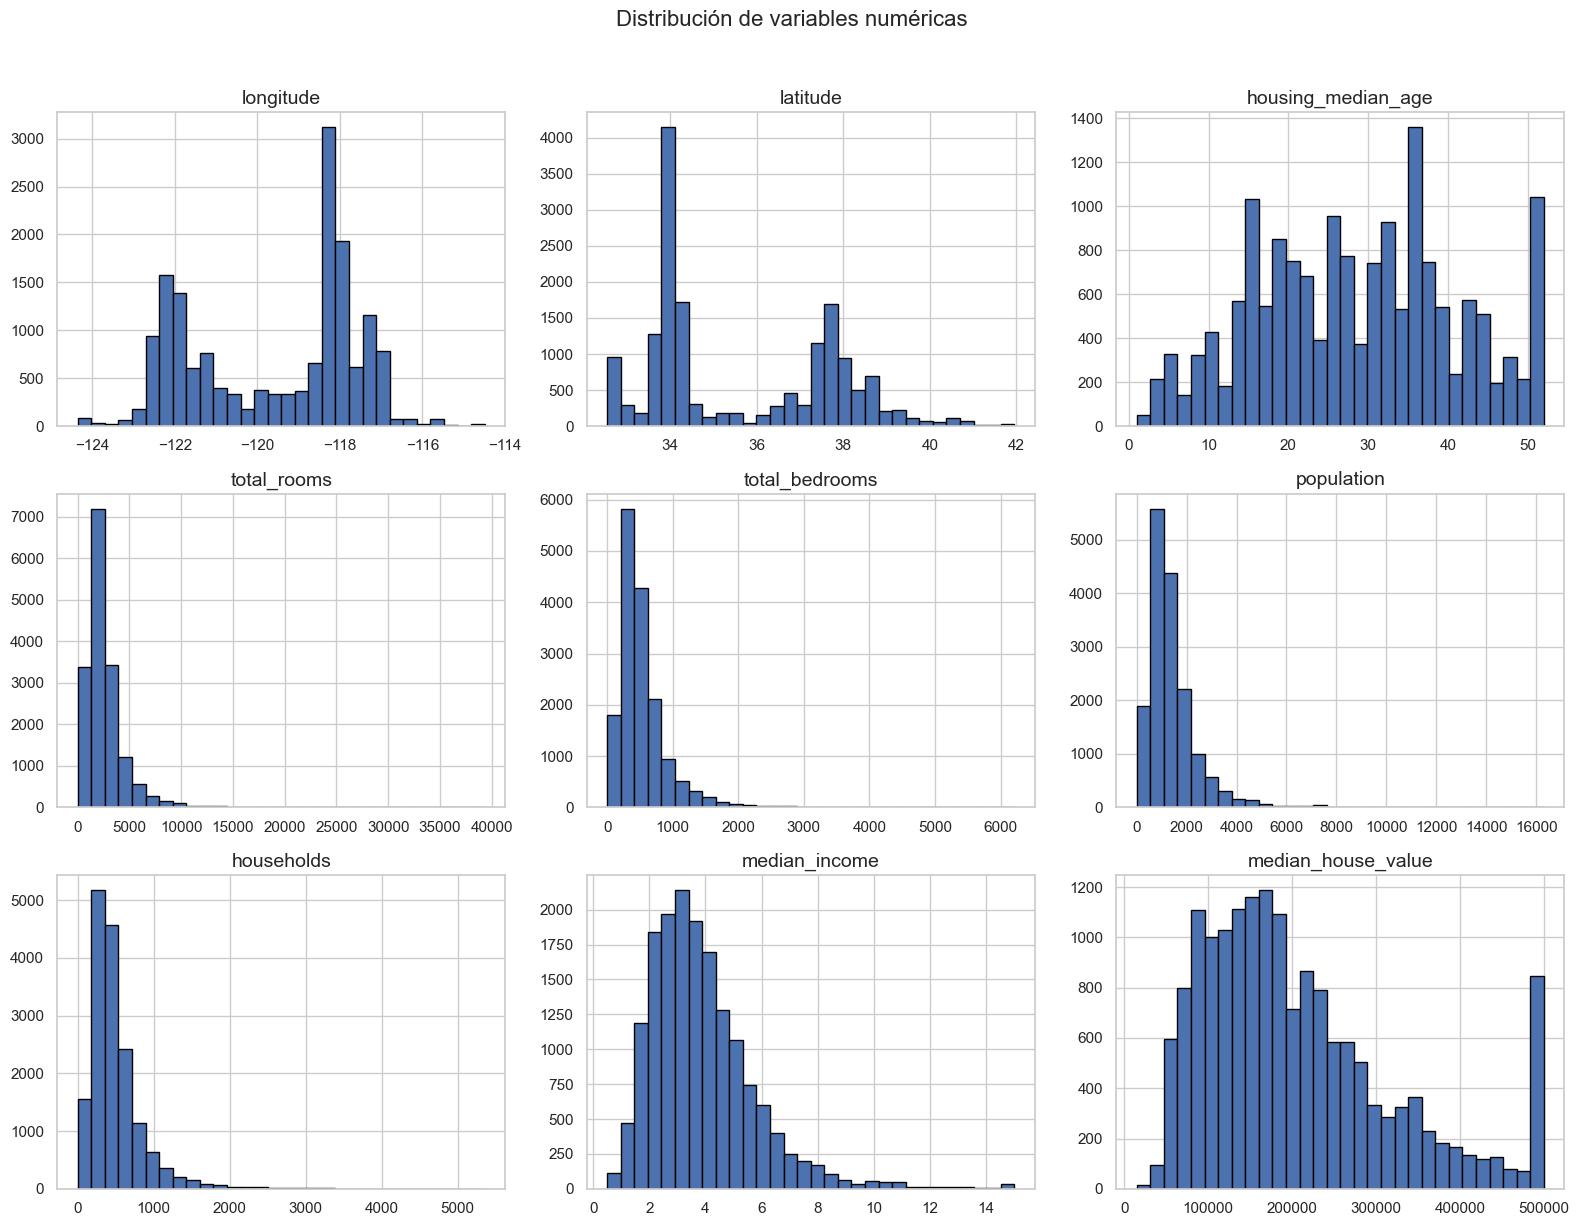


Hallazgos:
- Variables como total_rooms, total_bedrooms, population y households muestran asimetría positiva.
- Esto sugiere presencia de valores extremos y distribuciones sesgadas.
- median_income luce más estable y con mayor potencial predictivo.
- La variable objetivo median_house_value parece presentar acumulación en el extremo superior,
  lo que sugiere truncamiento/censura del dataset.



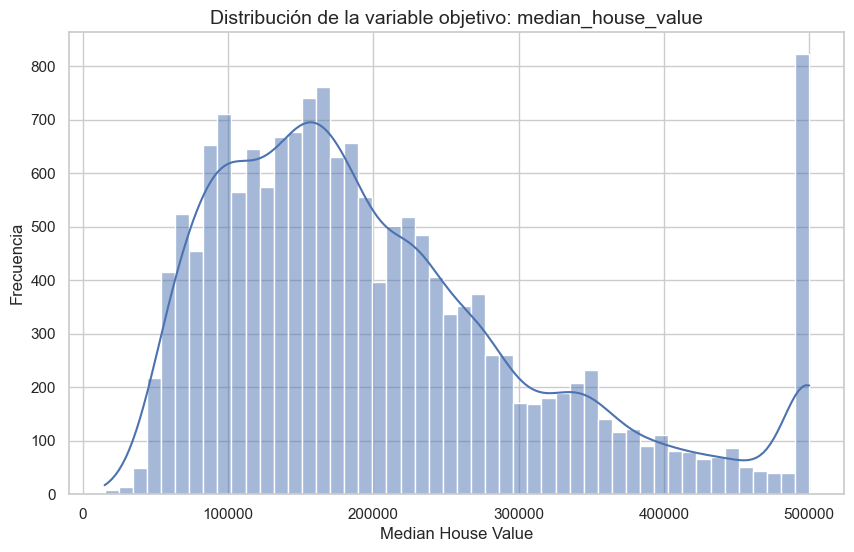

count     16512.000000
mean     206333.518653
std      115314.047529
min       14999.000000
25%      119200.000000
50%      179200.000000
75%      263925.000000
max      500001.000000
Name: median_house_value, dtype: float64

Interpretación:
La variable objetivo presenta una concentración importante en su límite superior cercano a 500,000.
Esto sugiere truncamiento en el dataset original, lo que puede limitar la capacidad del modelo para
aprender correctamente viviendas de muy alto valor.



<Figure size 1000x700 with 0 Axes>

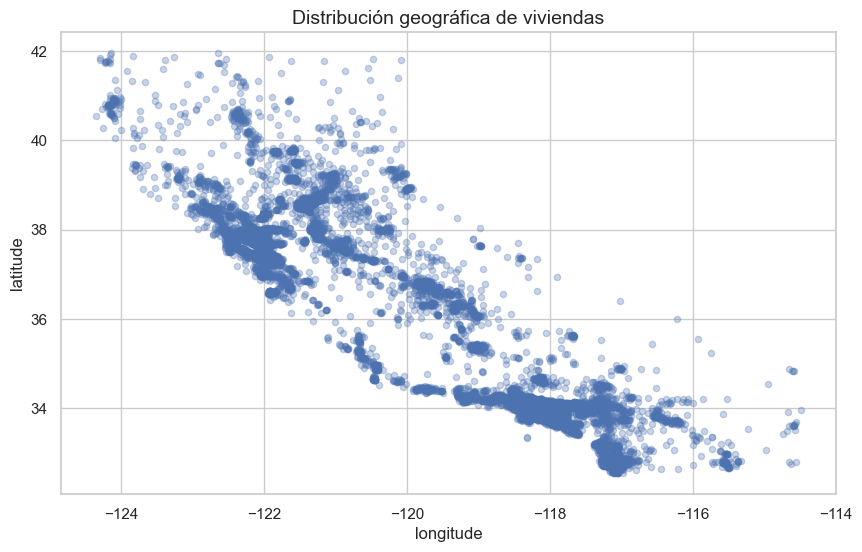


Interpretación:
Se observa una concentración importante de distritos habitacionales en ciertas zonas de California,
especialmente en áreas urbanizadas y cercanas a la costa.
La geografía probablemente tendrá un peso estructural en la explicación del precio.



<Figure size 1000x700 with 0 Axes>

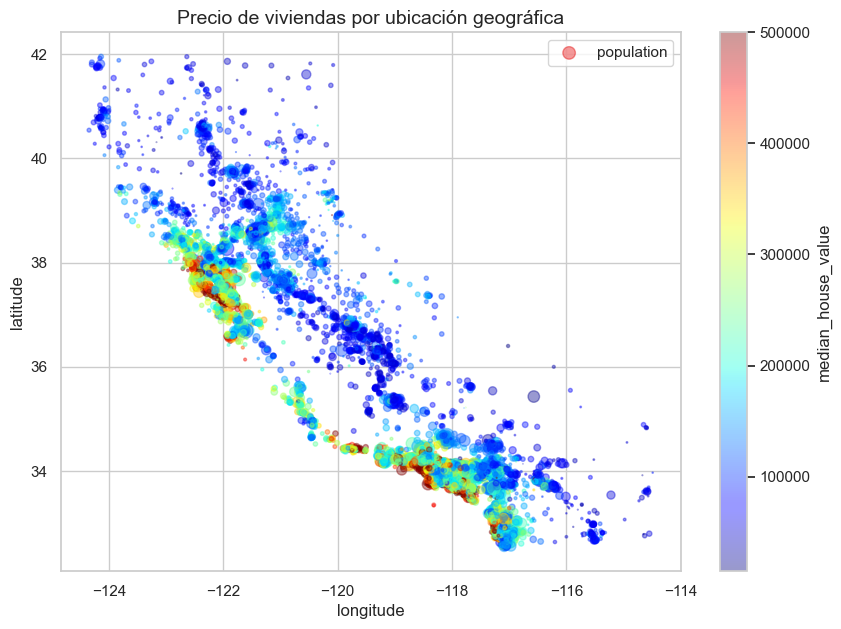


Interpretación:
Las zonas costeras y de mayor urbanización presentan precios más elevados.
Esto confirma que la ubicación geográfica es un determinante fundamental del valor de la vivienda.
Desde una perspectiva de negocio, la cercanía a la costa y el acceso a servicios elevan el precio inmobiliario.



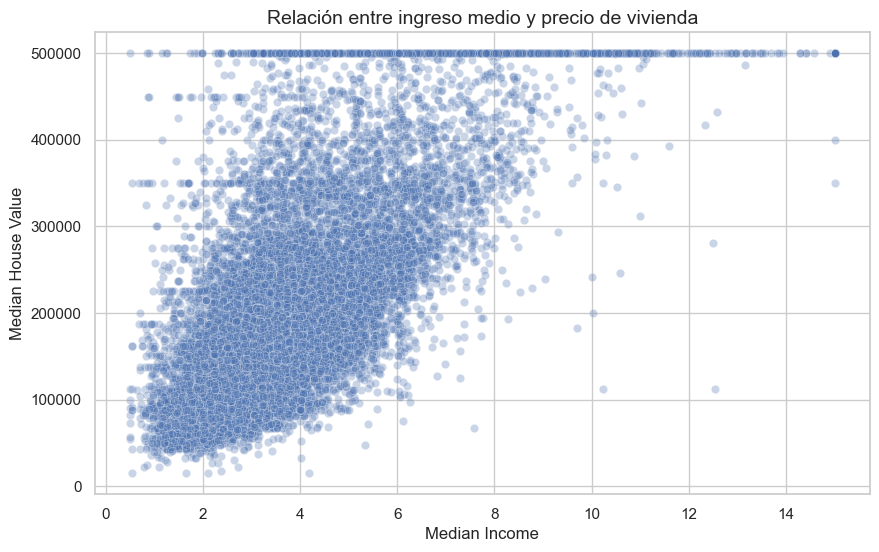


Interpretación:
Existe una relación positiva clara entre ingreso medio y precio de vivienda.
A medida que aumenta el ingreso del distrito, el valor de las viviendas también tiende a aumentar.
Además, se aprecia heterocedasticidad: la dispersión del precio crece conforme aumenta el ingreso.



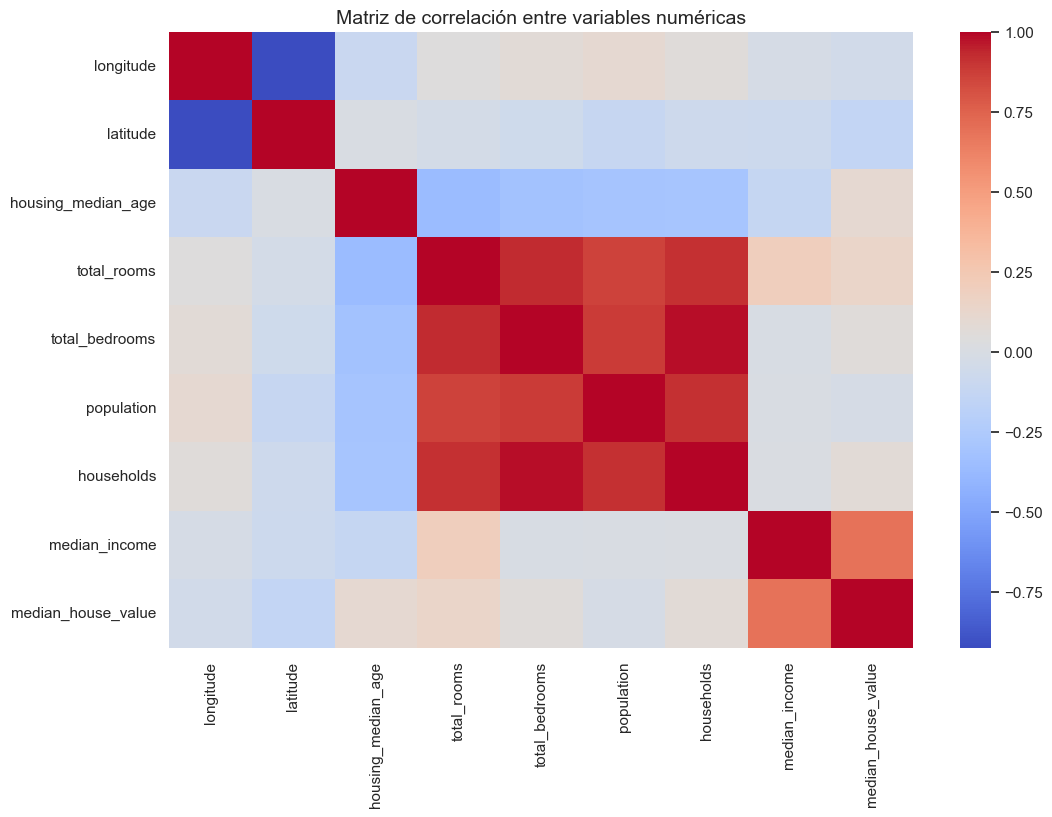


Correlación con la variable objetivo:


median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


Interpretación:
median_income presenta la mayor correlación positiva con median_house_value,
lo cual la posiciona como la variable individual más relevante.
Las variables estructurales del hogar también muestran relaciones entre sí,
lo que sugiere multicolinealidad.



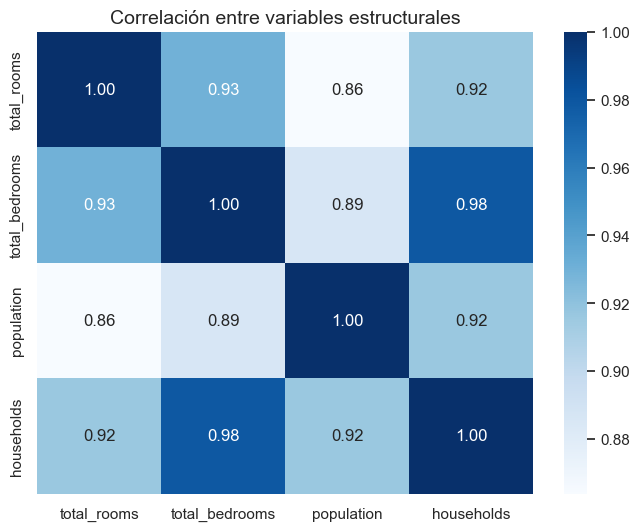


Interpretación:
Se observa alta correlación entre total_rooms, total_bedrooms, population y households.
Esto sugiere redundancia parcial de información.
En modelos lineales, esta multicolinealidad puede afectar estabilidad e interpretación;
en modelos basados en árboles suele ser menos problemática.



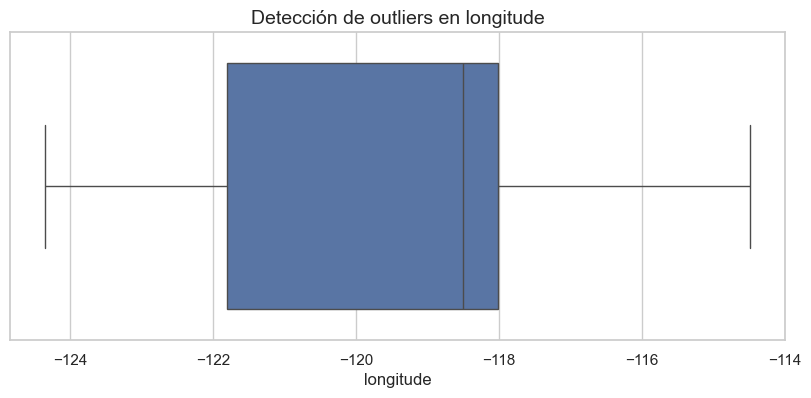

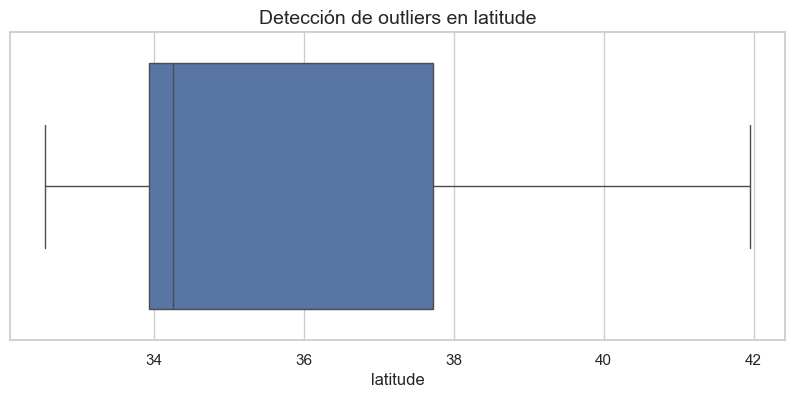

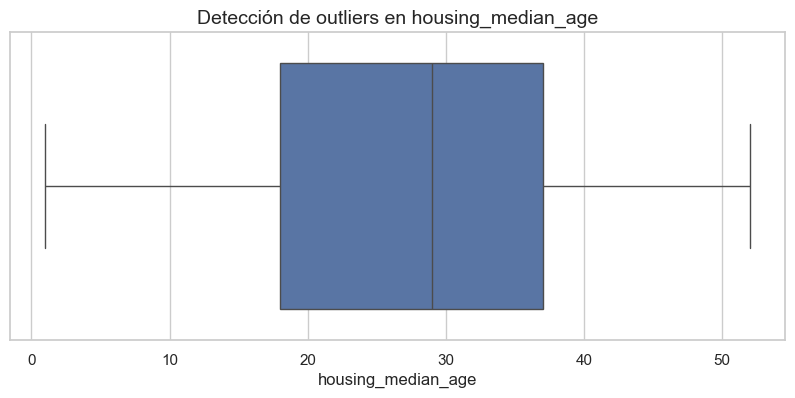

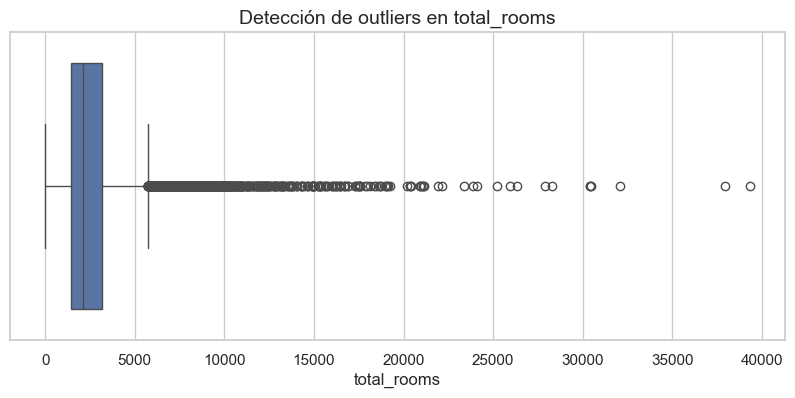

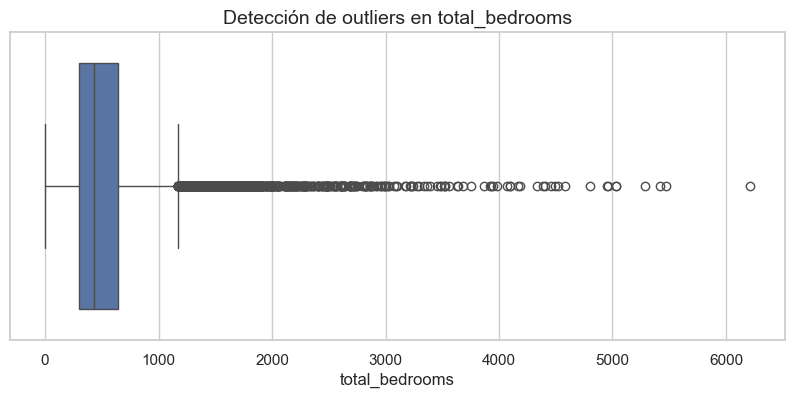

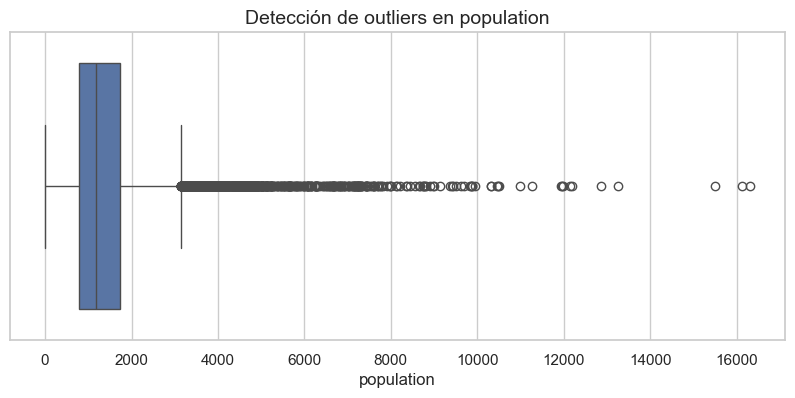

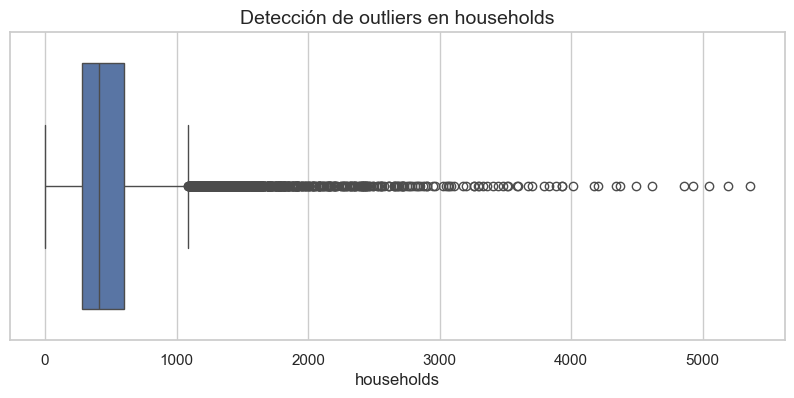

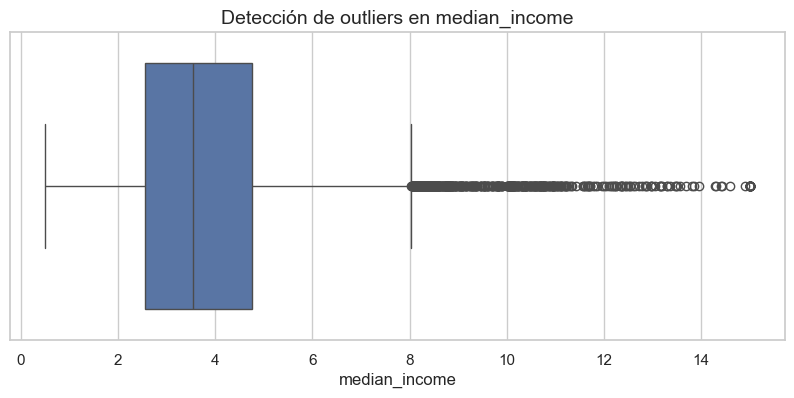

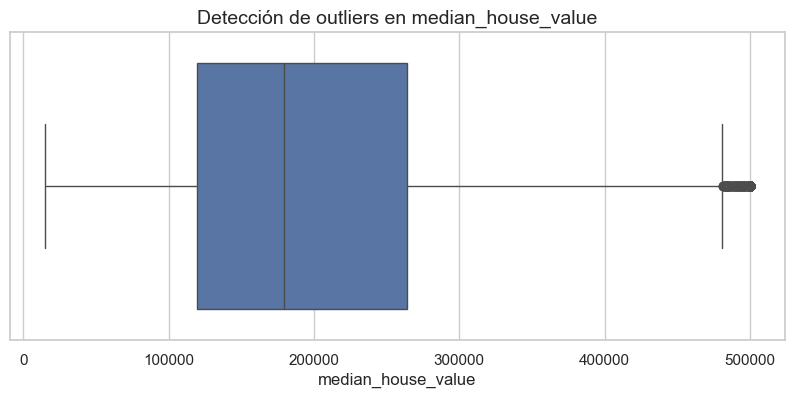


Hallazgos:
Se detectan valores atípicos importantes en total_rooms, total_bedrooms, population, households y median_income.
Estos outliers no necesariamente son errores; podrían representar distritos reales con características extremas.
Sin embargo, conviene considerar transformaciones o variables derivadas para mejorar el modelado.


Distribución de ocean_proximity:


ocean_proximity
<1H OCEAN     7274
INLAND        5301
NEAR OCEAN    2089
NEAR BAY      1846
ISLAND           2
Name: count, dtype: int64

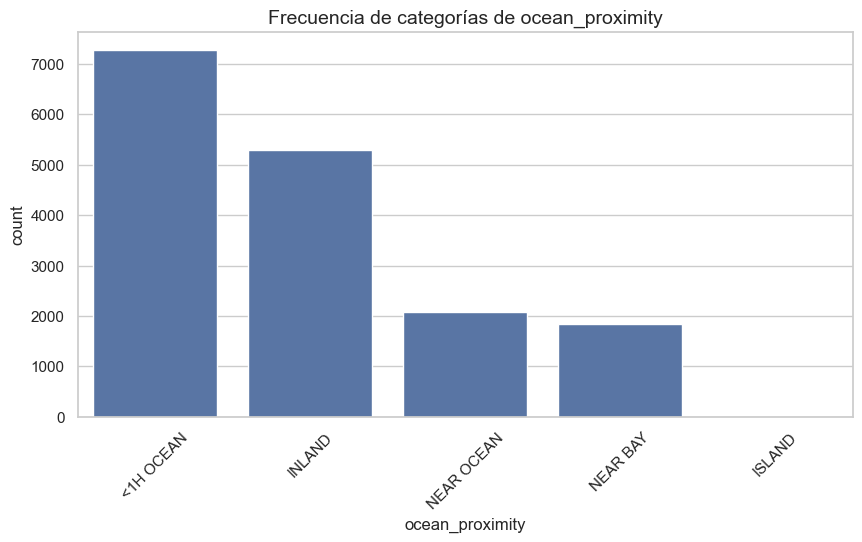


Interpretación:
La variable categórica ocean_proximity está desbalanceada.
Las categorías más frecuentes son '<1H OCEAN' e 'INLAND', mientras que 'ISLAND' es prácticamente marginal.
Esto sugiere que la codificación de esta variable será importante y que algunas categorías raras
podrían aportar poco valor estadístico al modelo.



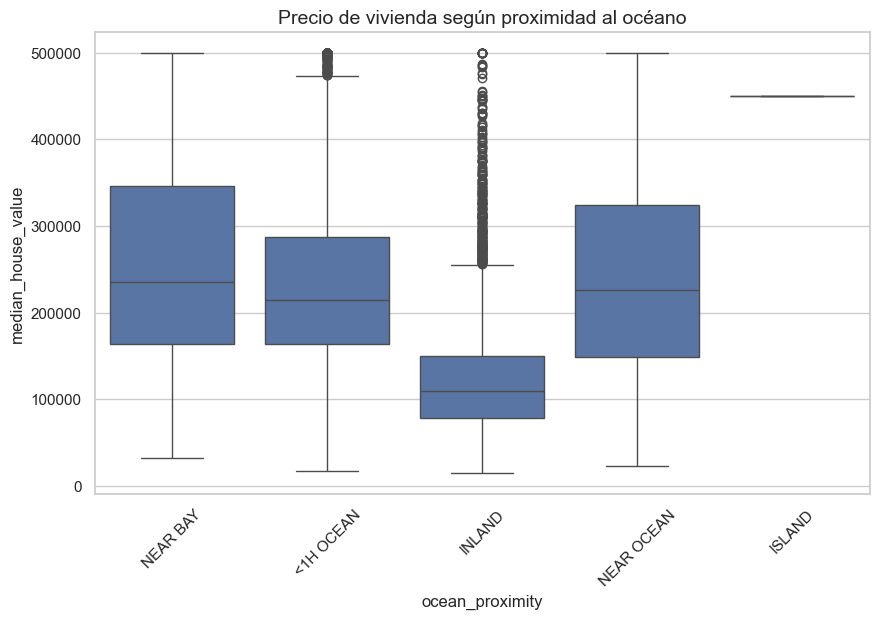


Interpretación:
La cercanía al océano muestra diferencias claras en el precio de las viviendas.
Las categorías relacionadas con costa o bahía tienden a presentar precios medianos más elevados,
mientras que INLAND concentra valores más bajos.
Esto confirma que ocean_proximity captura una dimensión económica importante del mercado inmobiliario.


Correlación incluyendo variables derivadas exploratorias:


median_house_value          1.000000
median_income               0.688380
rooms_per_household         0.143663
total_rooms                 0.137455
housing_median_age          0.102175
households                  0.071426
total_bedrooms              0.054635
population                 -0.020153
population_per_household   -0.038224
longitude                  -0.050859
latitude                   -0.139584
bedrooms_per_room          -0.256397
Name: median_house_value, dtype: float64

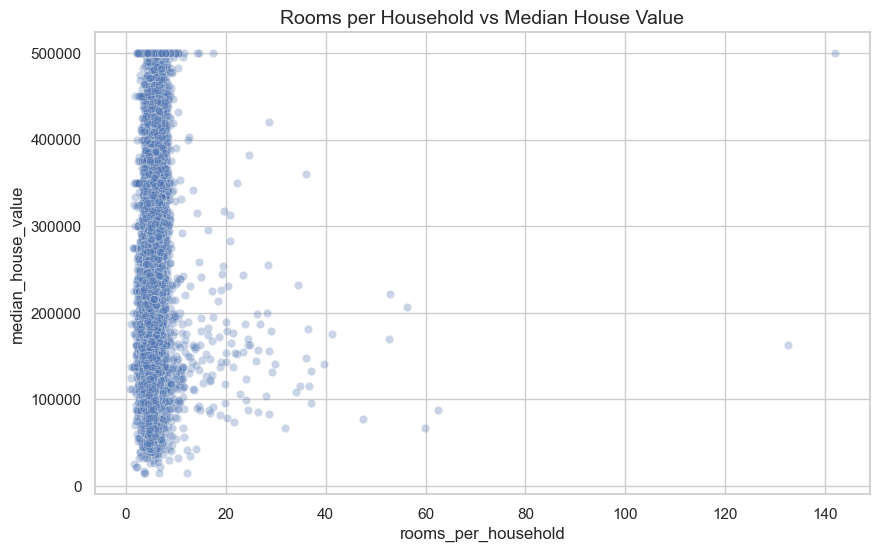

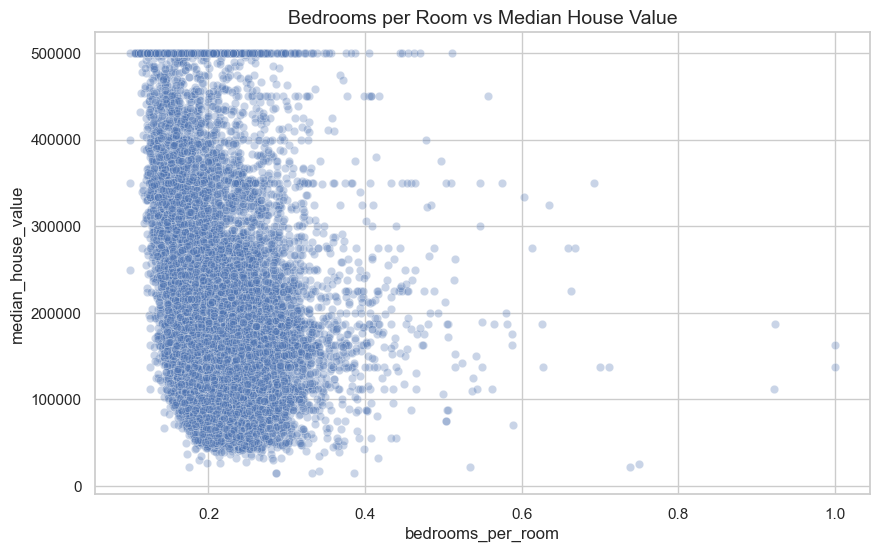

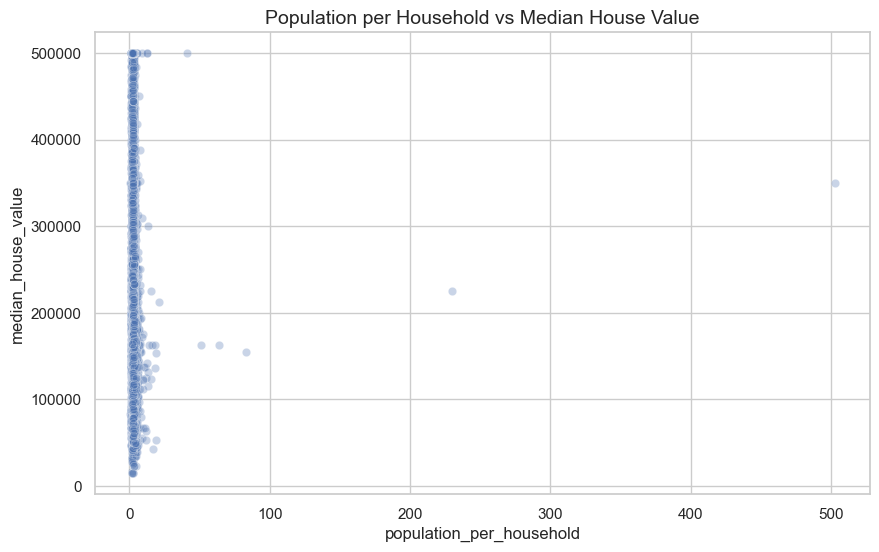


Interpretación:
Las variables derivadas pueden capturar mejor la estructura real de los distritos que las variables absolutas.
Por ejemplo:
- rooms_per_household aproxima amplitud promedio de vivienda
- bedrooms_per_room aproxima densidad interna del inmueble
- population_per_household aproxima hacinamiento o densidad residencial
Estas variables suelen ser más informativas para modelos predictivos que los conteos brutos.



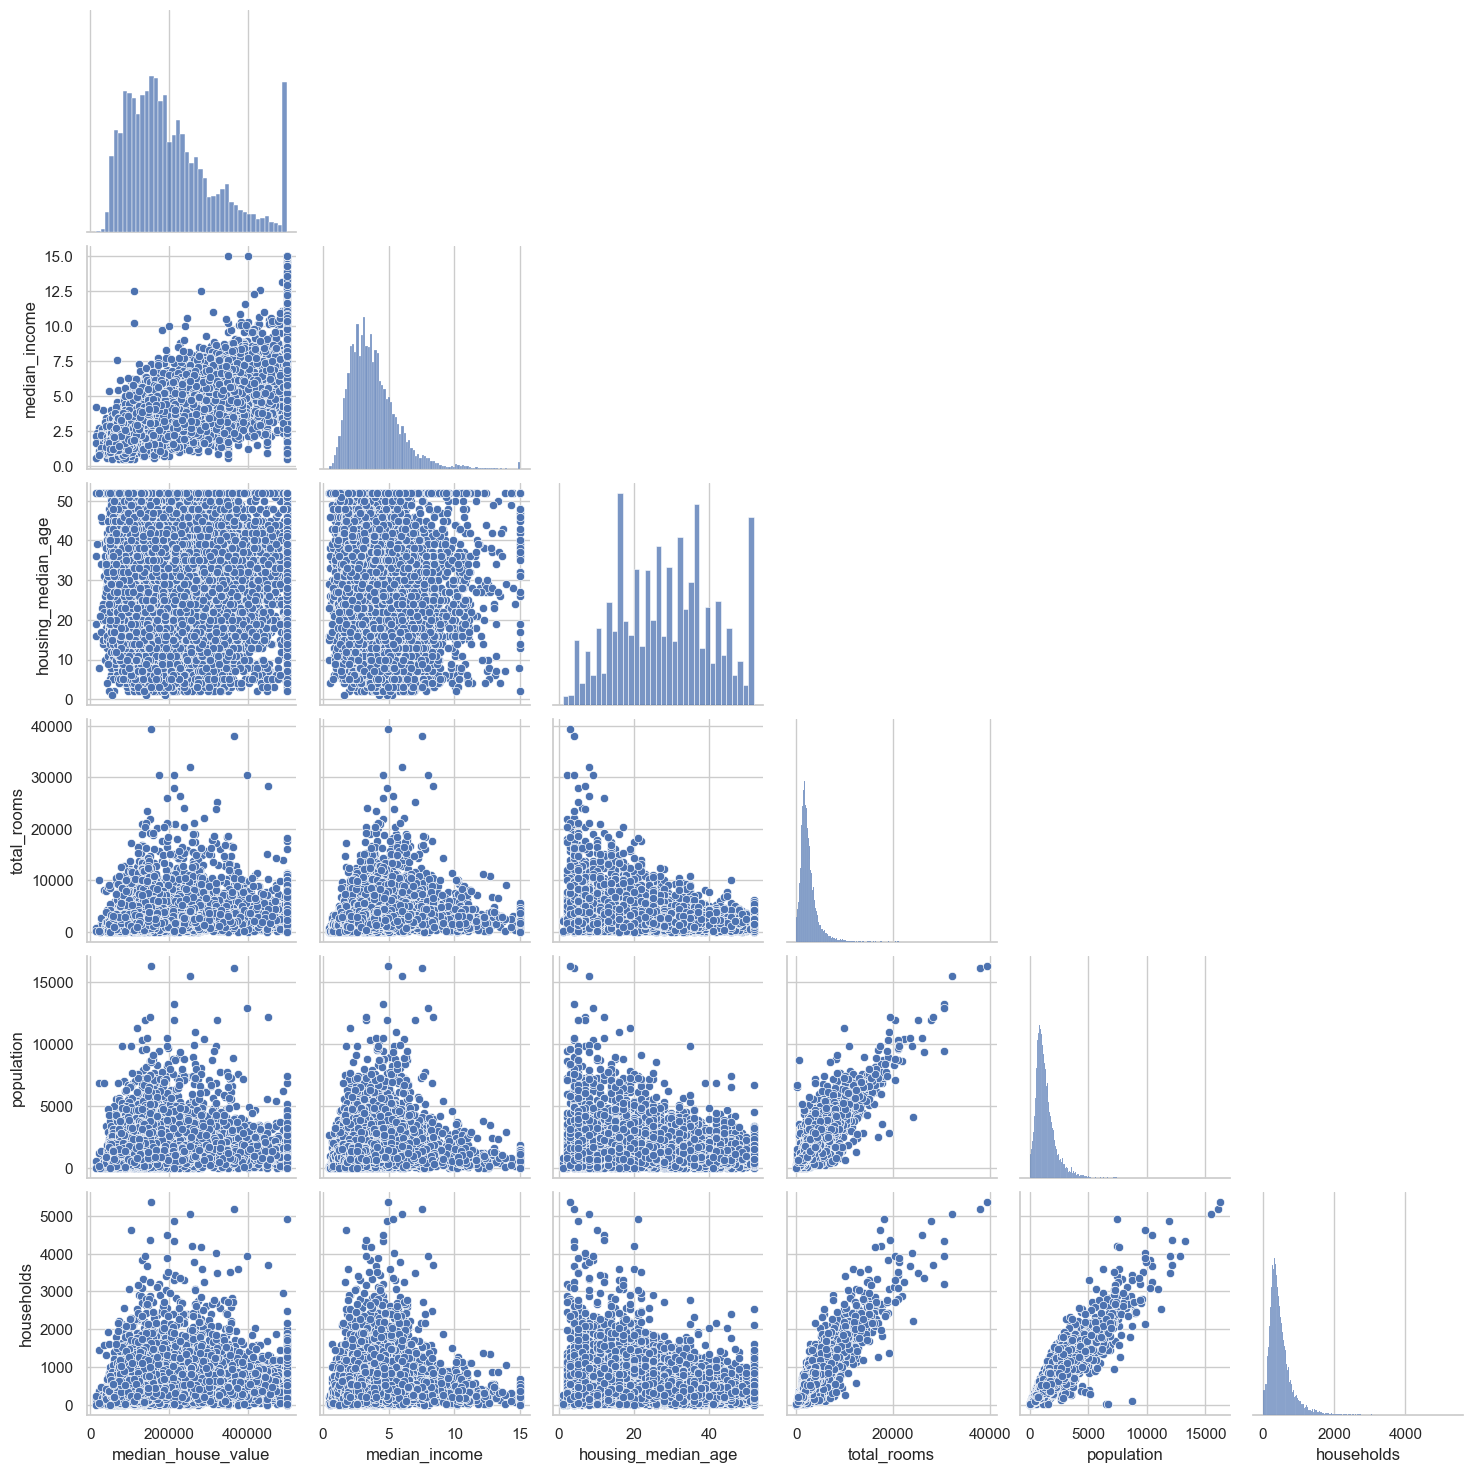


Interpretación:
El pairplot confirma visualmente que median_income tiene la relación más fuerte con la variable objetivo.
También permite detectar patrones no lineales, dispersión desigual y posibles agrupamientos entre variables.


CONCLUSIONES ESTRATÉGICAS

1. median_income es la variable con mayor poder explicativo individual sobre el precio de la vivienda.

2. La ubicación geográfica influye fuertemente en el valor inmobiliario:
   las zonas costeras y cercanas a la bahía presentan precios más altos.

3. Existen valores faltantes en total_bedrooms, por lo que será necesaria una imputación en la fase de preprocesamiento.

4. Las variables total_rooms, total_bedrooms, population y households presentan asimetría positiva y outliers importantes.

5. Se detecta multicolinealidad entre variables estructurales del hogar,
   por lo que conviene evaluar variables derivadas y modelos robustos.

6. La variable objetivo median_house_value parece truncada en su límite superior,
   lo que puede

In [5]:
# ============================================================
# 01_exploracion.ipynb
# Análisis Exploratorio de Datos (EDA) - Proyecto Final USFQ
# ============================================================

# =========================
# 1. LIBRERÍAS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Carpeta opcional para guardar imágenes
IMAGES_PATH = Path("../reports/images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(IMAGES_PATH / f"{name}.png", dpi=300, bbox_inches="tight")


# =========================
# 2. CARGA DE DATOS
# =========================
# Se recomienda hacer el EDA sobre training set para evitar data leakage
train = pd.read_csv("../data/interim/train_set.csv")

print("Dimensiones del dataset de entrenamiento:", train.shape)
display(train.head())


# =========================
# 3. INSPECCIÓN GENERAL
# =========================
print("\n--- INFO GENERAL ---")
train.info()

print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(train.describe(include="all"))

print("\n--- VALORES FALTANTES ---")
missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (train.isnull().mean() * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({
    "n_missing": missing,
    "%_missing": missing_pct.round(2)
})
display(missing_df[missing_df["n_missing"] > 0])

# Comentario interpretativo
print("""
Conclusión inicial:
El conjunto de entrenamiento contiene variables numéricas y una variable categórica ('ocean_proximity').
La principal incidencia de calidad de datos corresponde a valores faltantes en 'total_bedrooms', 
los cuales deberán imputarse en la fase de preprocesamiento.
""")


# =========================
# 4. TIPOS DE VARIABLES
# =========================
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)


# =========================
# 5. HISTOGRAMAS DE VARIABLES NUMÉRICAS
# =========================
train[num_cols].hist(bins=30, figsize=(16, 12), edgecolor="black")
plt.suptitle("Distribución de variables numéricas", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

print("""
Hallazgos:
- Variables como total_rooms, total_bedrooms, population y households muestran asimetría positiva.
- Esto sugiere presencia de valores extremos y distribuciones sesgadas.
- median_income luce más estable y con mayor potencial predictivo.
- La variable objetivo median_house_value parece presentar acumulación en el extremo superior,
  lo que sugiere truncamiento/censura del dataset.
""")


# =========================
# 6. ANÁLISIS DE LA VARIABLE OBJETIVO
# =========================
plt.figure(figsize=(10, 6))
sns.histplot(train["median_house_value"], bins=50, kde=True)
plt.title("Distribución de la variable objetivo: median_house_value")
plt.xlabel("Median House Value")
plt.ylabel("Frecuencia")
plt.show()

print(train["median_house_value"].describe())

print("""
Interpretación:
La variable objetivo presenta una concentración importante en su límite superior cercano a 500,000.
Esto sugiere truncamiento en el dataset original, lo que puede limitar la capacidad del modelo para
aprender correctamente viviendas de muy alto valor.
""")


# =========================
# 7. ANÁLISIS GEOGRÁFICO BÁSICO
# =========================
plt.figure(figsize=(10, 7))
train.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.3
)
plt.title("Distribución geográfica de viviendas")
plt.show()

print("""
Interpretación:
Se observa una concentración importante de distritos habitacionales en ciertas zonas de California,
especialmente en áreas urbanizadas y cercanas a la costa.
La geografía probablemente tendrá un peso estructural en la explicación del precio.
""")


# =========================
# 8. MAPA DE PRECIOS POR UBICACIÓN
# =========================
plt.figure(figsize=(10, 7))
train.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=train["population"] / 100,
    label="population",
    c="median_house_value",
    cmap="jet",
    colorbar=True,
    figsize=(10, 7)
)
plt.legend()
plt.title("Precio de viviendas por ubicación geográfica")
plt.show()

print("""
Interpretación:
Las zonas costeras y de mayor urbanización presentan precios más elevados.
Esto confirma que la ubicación geográfica es un determinante fundamental del valor de la vivienda.
Desde una perspectiva de negocio, la cercanía a la costa y el acceso a servicios elevan el precio inmobiliario.
""")


# =========================
# 9. RELACIÓN ENTRE INGRESO Y PRECIO
# =========================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="median_income",
    y="median_house_value",
    data=train,
    alpha=0.3
)
plt.title("Relación entre ingreso medio y precio de vivienda")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

print("""
Interpretación:
Existe una relación positiva clara entre ingreso medio y precio de vivienda.
A medida que aumenta el ingreso del distrito, el valor de las viviendas también tiende a aumentar.
Además, se aprecia heterocedasticidad: la dispersión del precio crece conforme aumenta el ingreso.
""")


# =========================
# 10. MATRIZ DE CORRELACIÓN
# =========================
corr_matrix = train.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

target_corr = corr_matrix["median_house_value"].sort_values(ascending=False)
print("\nCorrelación con la variable objetivo:")
display(target_corr)

print("""
Interpretación:
median_income presenta la mayor correlación positiva con median_house_value,
lo cual la posiciona como la variable individual más relevante.
Las variables estructurales del hogar también muestran relaciones entre sí,
lo que sugiere multicolinealidad.
""")


# =========================
# 11. MULTICOLINEALIDAD ENTRE VARIABLES ESTRUCTURALES
# =========================
structural_vars = ["total_rooms", "total_bedrooms", "population", "households"]
plt.figure(figsize=(8, 6))
sns.heatmap(train[structural_vars].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlación entre variables estructurales")
plt.show()

print("""
Interpretación:
Se observa alta correlación entre total_rooms, total_bedrooms, population y households.
Esto sugiere redundancia parcial de información.
En modelos lineales, esta multicolinealidad puede afectar estabilidad e interpretación;
en modelos basados en árboles suele ser menos problemática.
""")


# =========================
# 12. BOXPLOTS DE VARIABLES NUMÉRICAS
# =========================
for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=train[col])
    plt.title(f"Detección de outliers en {col}")
    plt.show()

print("""
Hallazgos:
Se detectan valores atípicos importantes en total_rooms, total_bedrooms, population, households y median_income.
Estos outliers no necesariamente son errores; podrían representar distritos reales con características extremas.
Sin embargo, conviene considerar transformaciones o variables derivadas para mejorar el modelado.
""")


# =========================
# 13. ANÁLISIS DE VARIABLE CATEGÓRICA
# =========================
print("\nDistribución de ocean_proximity:")
display(train["ocean_proximity"].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(data=train, x="ocean_proximity", order=train["ocean_proximity"].value_counts().index)
plt.title("Frecuencia de categorías de ocean_proximity")
plt.xticks(rotation=45)
plt.show()

print("""
Interpretación:
La variable categórica ocean_proximity está desbalanceada.
Las categorías más frecuentes son '<1H OCEAN' e 'INLAND', mientras que 'ISLAND' es prácticamente marginal.
Esto sugiere que la codificación de esta variable será importante y que algunas categorías raras
podrían aportar poco valor estadístico al modelo.
""")


# =========================
# 14. VARIABLE CATEGÓRICA VS TARGET
# =========================
plt.figure(figsize=(10, 6))
sns.boxplot(x="ocean_proximity", y="median_house_value", data=train)
plt.title("Precio de vivienda según proximidad al océano")
plt.xticks(rotation=45)
plt.show()

print("""
Interpretación:
La cercanía al océano muestra diferencias claras en el precio de las viviendas.
Las categorías relacionadas con costa o bahía tienden a presentar precios medianos más elevados,
mientras que INLAND concentra valores más bajos.
Esto confirma que ocean_proximity captura una dimensión económica importante del mercado inmobiliario.
""")


# =========================
# 15. ANÁLISIS DE VARIABLES DERIVADAS (EXPLORATORIO)
# =========================
# Creamos variables solo para explorar patrones; la lógica formal irá luego a build_features.py
train_eda = train.copy()

train_eda["rooms_per_household"] = train_eda["total_rooms"] / train_eda["households"]
train_eda["bedrooms_per_room"] = train_eda["total_bedrooms"] / train_eda["total_rooms"]
train_eda["population_per_household"] = train_eda["population"] / train_eda["households"]

eda_corr = train_eda.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)
print("\nCorrelación incluyendo variables derivadas exploratorias:")
display(eda_corr)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="rooms_per_household",
    y="median_house_value",
    data=train_eda,
    alpha=0.3
)
plt.title("Rooms per Household vs Median House Value")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="bedrooms_per_room",
    y="median_house_value",
    data=train_eda,
    alpha=0.3
)
plt.title("Bedrooms per Room vs Median House Value")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="population_per_household",
    y="median_house_value",
    data=train_eda,
    alpha=0.3
)
plt.title("Population per Household vs Median House Value")
plt.show()

print("""
Interpretación:
Las variables derivadas pueden capturar mejor la estructura real de los distritos que las variables absolutas.
Por ejemplo:
- rooms_per_household aproxima amplitud promedio de vivienda
- bedrooms_per_room aproxima densidad interna del inmueble
- population_per_household aproxima hacinamiento o densidad residencial
Estas variables suelen ser más informativas para modelos predictivos que los conteos brutos.
""")


# =========================
# 16. RELACIONES ENTRE VARIABLES CLAVE
# =========================
selected_vars = [
    "median_house_value",
    "median_income",
    "housing_median_age",
    "total_rooms",
    "population",
    "households"
]

sns.pairplot(train[selected_vars], corner=True)
plt.show()

print("""
Interpretación:
El pairplot confirma visualmente que median_income tiene la relación más fuerte con la variable objetivo.
También permite detectar patrones no lineales, dispersión desigual y posibles agrupamientos entre variables.
""")


# =========================
# 17. RESUMEN EJECUTIVO DEL EDA
# =========================
print("""
=========================
CONCLUSIONES ESTRATÉGICAS
=========================

1. median_income es la variable con mayor poder explicativo individual sobre el precio de la vivienda.

2. La ubicación geográfica influye fuertemente en el valor inmobiliario:
   las zonas costeras y cercanas a la bahía presentan precios más altos.

3. Existen valores faltantes en total_bedrooms, por lo que será necesaria una imputación en la fase de preprocesamiento.

4. Las variables total_rooms, total_bedrooms, population y households presentan asimetría positiva y outliers importantes.

5. Se detecta multicolinealidad entre variables estructurales del hogar,
   por lo que conviene evaluar variables derivadas y modelos robustos.

6. La variable objetivo median_house_value parece truncada en su límite superior,
   lo que puede limitar la predicción de viviendas de mayor valor.

7. La variable ocean_proximity tiene alto valor explicativo,
   aunque presenta desbalance en sus categorías.

8. Las variables derivadas como rooms_per_household, bedrooms_per_room y population_per_household
   muestran potencial para mejorar el desempeño predictivo del modelo.
""")


# =========================
# 18. IMPLICACIONES PARA MODELADO
# =========================
print("""
=========================
IMPLICACIONES PARA MODELADO
=========================

- Imputar valores faltantes de total_bedrooms
- Codificar la variable categórica ocean_proximity con One-Hot Encoding
- Crear variables derivadas estructurales
- Considerar transformaciones para variables sesgadas
- Evaluar modelos robustos frente a multicolinealidad y relaciones no lineales
- Analizar cuidadosamente el sobreajuste/subajuste en modelos complejos
""")